In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def read_jsonl(path):
  rows = []
  with open(path, "r", encoding="utf-8") as f:
    for line in f:
      line = line.strip()
      if line:
        rows.append(json.loads(line))
  return rows

In [3]:
def load_split(split_dir):
  split_dir = Path(split_dir)
  jsonl_path = split_dir / (split_dir.name + ".jsonl")
  data = read_jsonl(jsonl_path)
  df = pd.json_normalize(data)

  # Helpful columns
  if "fields.total" in df.columns:
    df["fields.total_num"] = pd.to_numeric(df["fields.total"], errors="coerce")

  return df


=== TRAIN COLUMNS ===
['id', 'image_path', 'fields.vendor', 'fields.date', 'fields.total', 'label.is_forged', 'label.fraud_type', 'fields.total_num']

=== TRAIN HEAD ===
     id       image_path fields.vendor fields.date fields.total  \
0  r001  images/r001.png     ACME Corp  2024-01-24       141.14   
1  r002  images/r002.png     Gulf Mart  2024-12-04       339.97   
2  r003  images/r003.png    Quick Shop  2024-02-19       213.85   

   label.is_forged label.fraud_type  fields.total_num  
0                0             none            141.14  
1                1     price_change            339.97  
2                0             none            213.85  

=== BASIC SANITY CHECKS ===
Train rows: 20
Test rows: 10

Class balance (train):
label.is_forged
0    10
1    10
Name: count, dtype: int64

Missing values (train):
fields.vendor      0.0
fields.date        0.0
fields.total       0.0
label.is_forged    0.0
dtype: float64


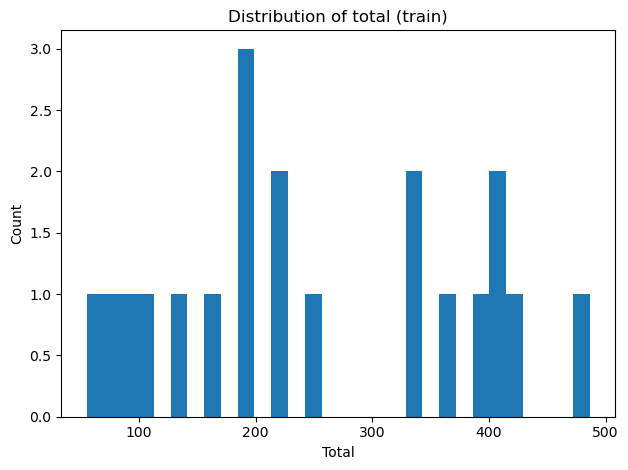

fields.vendor
Quick Shop      176.727500
ACME Corp       243.380000
City Store      251.413333
Gulf Mart       266.400000
Star Traders    334.552500
Name: fields.total_num, dtype: float64

In [ ]:

base = Path(r"C:\ML\dummy_data")

train_dir = base / "train"
test_dir = base / "test"

train_df = load_split(train_dir)
test_df = load_split(test_dir)

print("\n=== TRAIN COLUMNS ===")
print(train_df.columns.tolist())

print("\n=== TRAIN HEAD ===")
print(train_df.head(3))

print("\n=== BASIC SANITY CHECKS ===")
print("Train rows:", len(train_df))
print("Test rows:", len(test_df))

if "label.is_forged" in train_df.columns:
  print("\nClass balance (train):")
  print(train_df["label.is_forged"].value_counts(dropna=False))

print("\nMissing values (train):")
cols = [c for c in ["fields.vendor", "fields.date", "fields.total", "label.is_forged"] if c in train_df.columns]
print(train_df[cols].isna().mean().sort_values(ascending=False))

# Plot totals if present
if "fields.total_num" in train_df.columns:
  plt.figure()
  train_df["fields.total_num"].dropna().plot(kind="hist", bins=30)
  plt.title("Distribution of total (train)")
  plt.xlabel("Total")
  plt.ylabel("Count")
  plt.tight_layout()
  plt.show()
  
train_df.groupby("fields.vendor")["fields.total_num"].mean().sort_values()